# 01 — Dataset & Problem Analysis

**Purpose:** Exploratory data analysis establishing empirical evidence for the Amorphous Bottleneck.

1. Class distribution and dataset composition
2. Object scale analysis with rescaled COCO thresholds
3. Weber contrast analysis
4. Figure generation for thesis (Figures 1, 2, 3)

In [3]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
DATA_ROOT = r"C:\Users\dadab\Desktop\Clean Version\data"
DATASETS = {
    "Train": {"img": "train/images", "json": "train/train_annotations.json"},
    "Val":   {"img": "val/images",   "json": "val/val_annotations.json"},
    "Test":  {"img": "test/images",  "json": "test/test_annotations.json"},
}
OUTPUT_DIR = "figures/eda/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Data Extraction: Area and Weber Contrast

In [4]:
def measure_properties(img_path, polygon):
    """Calculate object area (pixels) and Weber contrast for one annotation."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Create object mask from polygon
    mask = np.zeros_like(img)
    pts = np.array(polygon).reshape(-1, 2).astype(np.int32)
    cv2.fillPoly(mask, [pts], 255)

    # Create background mask (dilated ring around object)
    kernel = np.ones((15, 15), np.uint8)
    bg_mask = cv2.subtract(cv2.dilate(mask, kernel), mask)

    # Compute metrics
    mean_obj = cv2.mean(img, mask=mask)[0]
    mean_bg = cv2.mean(img, mask=bg_mask)[0]

    contrast = abs(mean_obj - mean_bg) / (mean_bg + 1e-6)  # Weber contrast
    area = np.sum(mask > 0)

    return area, contrast


records = []
for split, paths in DATASETS.items():
    json_path = os.path.join(DATA_ROOT, paths["json"])
    img_dir = os.path.join(DATA_ROOT, paths["img"])
    if not os.path.exists(json_path):
        print(f"Warning: {json_path} not found, skipping {split}")
        continue

    with open(json_path, 'r') as f:
        coco = json.load(f)

    img_map = {i['id']: i['file_name'] for i in coco['images']}
    cat_map = {c['id']: c['name'] for c in coco['categories']}

    print(f"Processing {split}...")
    for ann in tqdm(coco['annotations']):
        fname = img_map.get(ann['image_id'])
        if not fname:
            continue
        res = measure_properties(os.path.join(img_dir, fname), ann['segmentation'])
        if res:
            records.append({
                "split": split, "class": cat_map.get(ann['category_id']),
                "area": res[0], "contrast": res[1], "image_id": ann['image_id'],
            })

df = pd.DataFrame(records)
print(f"\nTotal records: {len(df)}")

Processing Train...


100%|█████████████████████████████████████████████████████████████████████████████| 5386/5386 [00:35<00:00, 152.12it/s]


Processing Val...


100%|█████████████████████████████████████████████████████████████████████████████| 1830/1830 [00:12<00:00, 145.24it/s]


Processing Test...


100%|█████████████████████████████████████████████████████████████████████████████| 1812/1812 [00:11<00:00, 153.92it/s]


Total records: 9028


## 2. Dataset Summary Tables

In [5]:
# Class distribution
print("=== CLASS DISTRIBUTION ===")
print(df.pivot_table(index="class", columns="split", values="area", aggfunc="count").fillna(0))

# Dataset summary
print("\n=== DATASET SUMMARY ===")
summary = df.groupby("split").agg(
    n_images=("image_id", "nunique"),
    n_labels=("area", "count"),
)
summary["avg_labels_per_img"] = (summary["n_labels"] / summary["n_images"]).round(2)
print(summary)

=== CLASS DISTRIBUTION ===
split  Test  Train   Val
class                   
ac     1040   3038  1042
lc      772   2348   788

=== DATASET SUMMARY ===
       n_images  n_labels  avg_labels_per_img
split                                        
Test        591      1812                3.07
Train      1769      5386                3.04
Val         589      1830                3.11


## 3. Object Scale Analysis (Rescaled COCO Thresholds)

In [6]:
IMG_AREA = 1920 * 648
COCO_BASE_AREA = 640 * 480
scale_factor = IMG_AREA / COCO_BASE_AREA
new_small = 1024 * scale_factor
new_large = 9216 * scale_factor

total = len(df)
pct_small = len(df[df['area'] < new_small]) / total * 100
pct_medium = len(df[(df['area'] >= new_small) & (df['area'] < new_large)]) / total * 100
pct_large = len(df[df['area'] >= new_large]) / total * 100

print(f"=== RESCALED COCO THRESHOLDS (1920x648) ===")
print(f"Scale factor: {scale_factor:.2f}")
print(f"Small  (< {int(new_small)} px²): {pct_small:.1f}%")
print(f"Medium ({int(new_small)} - {int(new_large)} px²): {pct_medium:.1f}%")
print(f"Large  (> {int(new_large)} px²): {pct_large:.1f}%")

=== RESCALED COCO THRESHOLDS (1920x648) ===
Scale factor: 4.05
Small  (< 4147 px²): 3.5%
Medium (4147 - 37324 px²): 40.9%
Large  (> 37324 px²): 55.6%


## 4. Weber Contrast Statistics

In [7]:
mean_cw = df['contrast'].mean()
median_cw = df['contrast'].median()
below_02 = (df['contrast'] < 0.2).mean() * 100

print(f"=== WEBER CONTRAST STATISTICS ===")
print(f"Mean:   {mean_cw:.4f}")
print(f"Median: {median_cw:.4f}")
print(f"Below 0.2 threshold: {below_02:.2f}%")

=== WEBER CONTRAST STATISTICS ===
Mean:   0.0824
Median: 0.0709
Below 0.2 threshold: 95.67%


## 5. Generate Thesis Figures

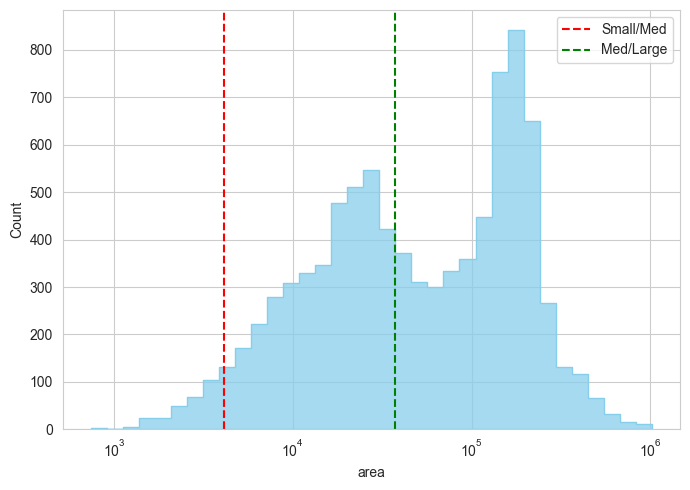

Saved: Figure 1


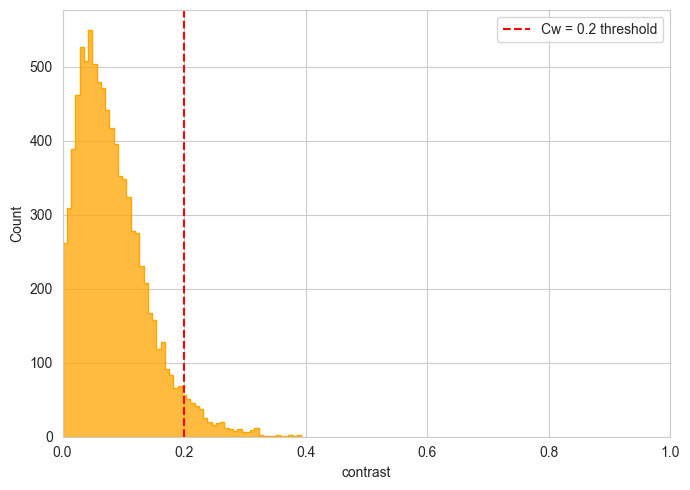

Saved: Figure 2


In [8]:
sns.set_style("whitegrid")

# Figure 1: Area Distribution
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="area", element="step", log_scale=True, color='skyblue')
plt.axvline(new_small, color='red', linestyle='--', label='Small/Med')
plt.axvline(new_large, color='green', linestyle='--', label='Med/Large')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure1_area_distribution.tiff', format='tiff', dpi=300,
            bbox_inches='tight', pil_kwargs={"compression": "tiff_lzw"})
plt.show()
print("Saved: Figure 1")

# Figure 2: Contrast Distribution
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="contrast", element="step", color='orange')
plt.axvline(0.2, color='red', linestyle='--', label='Cw = 0.2 threshold')
plt.xlim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure2_contrast_distribution.tiff', format='tiff', dpi=300,
            bbox_inches='tight', pil_kwargs={"compression": "tiff_lzw"})
plt.show()
print("Saved: Figure 2")

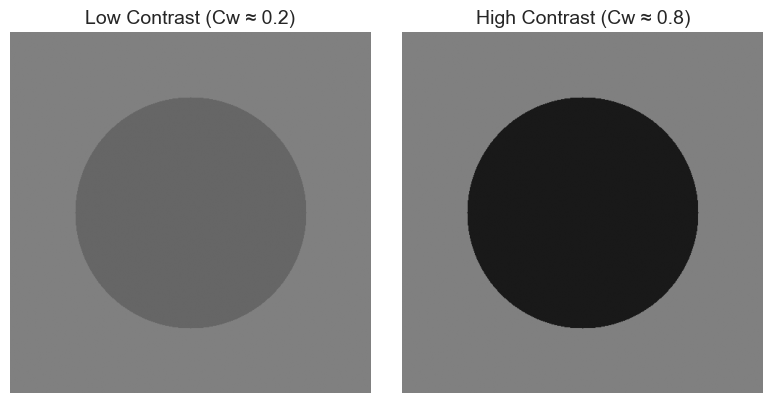

Saved: Figure 3


In [9]:
# Figure 3: Weber Contrast Visual Demonstration
img_size = 500
center = img_size // 2
radius = 160
y, x = np.ogrid[:img_size, :img_size]
mask = (x - center)**2 + (y - center)**2 <= radius**2

I_bg = 128
img_low = np.full((img_size, img_size), I_bg, dtype=np.uint8)
img_low[mask] = 102   # Cw ~ 0.2

img_high = np.full((img_size, img_size), I_bg, dtype=np.uint8)
img_high[mask] = 25   # Cw ~ 0.8

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_low, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Low Contrast (Cw ≈ 0.2)", fontsize=14)
axes[0].axis('off')
axes[1].imshow(img_high, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("High Contrast (Cw ≈ 0.8)", fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure3_contrast_comparison.tiff', format='tiff', dpi=300,
            bbox_inches='tight', pad_inches=0.1, pil_kwargs={"compression": "tiff_lzw"})
plt.show()
print("Saved: Figure 3")